# Python vs Pandas/NumPy Performance Comparison

## Stage 14: Bonus Performance Analysis

This notebook compares a preprocessing task implemented with raw Python
loops, lists, and dictionaries against an equivalent vectorized
implementation using Pandas and NumPy.

The comparison measures execution time, validates that both methods
produce equivalent results, and visualizes the runtime difference.

The original dataset is repeated only for timing stability. This
expanded benchmark dataset is not used for model training or evaluation.

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

In [2]:
import csv
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print("Project root:")
print(PROJECT_ROOT)

print("\nData path:")
print(DATA_PATH)

print("\nData file exists:")
print(DATA_PATH.exists())

Project root:
E:\Projects\DataMining

Data path:
E:\Projects\DataMining\data\raw\data.csv

Data file exists:
True


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The dataset file was not found.\n"
        f"Checked path: {DATA_PATH}"
    )


df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()


print("Dataset loaded successfully.")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")

Dataset loaded successfully.
Rows: 920
Columns: 16


## Benchmark Task

Both implementations perform the same preprocessing and descriptive
statistics task on continuous numeric features.

The task includes:

1. Selecting numeric features.
2. Treating zero values in `trestbps` and `chol` as missing.
3. Counting valid and missing values.
4. Calculating mean, median, minimum, maximum, variance, and standard
   deviation.

Data loading and conversion between data structures are excluded from
the measured runtime.

In [4]:
NUMERIC_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
]


SUSPICIOUS_ZERO_FEATURES = [
    "trestbps",
    "chol",
]


BENCHMARK_MULTIPLIER = 100
BENCHMARK_REPEATS = 5


missing_numeric_features = [
    feature
    for feature in NUMERIC_FEATURES
    if feature not in df_raw.columns
]


if missing_numeric_features:
    raise ValueError(
        f"Missing numeric features: {missing_numeric_features}"
    )


benchmark_df = pd.concat(
    [df_raw[NUMERIC_FEATURES]] * BENCHMARK_MULTIPLIER,
    ignore_index=True,
)


benchmark_records = benchmark_df.to_dict(
    orient="records"
)


benchmark_dataset_summary = pd.DataFrame(
    [
        {
            "original_rows": len(df_raw),
            "benchmark_multiplier": BENCHMARK_MULTIPLIER,
            "benchmark_rows": len(benchmark_df),
            "numeric_feature_count": len(NUMERIC_FEATURES),
            "benchmark_repeats": BENCHMARK_REPEATS,
            "used_for_modeling": False,
        }
    ]
)


display(benchmark_dataset_summary)

,original_rows,benchmark_multiplier,benchmark_rows,numeric_feature_count,benchmark_repeats,used_for_modeling
0,920,100,92000,5,5,False


In [7]:
def is_raw_missing(value):
    if value is None:
        return True

    try:
        return math.isnan(float(value))
    except (TypeError, ValueError):
        return False

In [8]:
def calculate_raw_python_summary(
    records,
    numeric_features,
    suspicious_zero_features,
):
    summary_rows = []

    for feature in numeric_features:
        valid_values = []
        missing_count = 0

        for record in records:
            value = record.get(feature)

            if is_raw_missing(value):
                missing_count += 1
                continue

            numeric_value = float(value)

            if (
                feature in suspicious_zero_features
                and numeric_value == 0
            ):
                missing_count += 1
                continue

            valid_values.append(numeric_value)

        valid_count = len(valid_values)

        if valid_count == 0:
            summary_rows.append(
                {
                    "feature": feature,
                    "valid_count": 0,
                    "missing_count": missing_count,
                    "mean": np.nan,
                    "median": np.nan,
                    "minimum": np.nan,
                    "maximum": np.nan,
                    "variance": np.nan,
                    "standard_deviation": np.nan,
                }
            )
            continue

        total_value = 0.0

        for value in valid_values:
            total_value += value

        mean_value = total_value / valid_count

        sorted_values = sorted(valid_values)
        middle_index = valid_count // 2

        if valid_count % 2 == 0:
            median_value = (
                sorted_values[middle_index - 1]
                + sorted_values[middle_index]
            ) / 2
        else:
            median_value = sorted_values[middle_index]

        minimum_value = valid_values[0]
        maximum_value = valid_values[0]

        for value in valid_values[1:]:
            if value < minimum_value:
                minimum_value = value

            if value > maximum_value:
                maximum_value = value

        squared_deviation_sum = 0.0

        for value in valid_values:
            squared_deviation_sum += (
                value - mean_value
            ) ** 2

        if valid_count > 1:
            variance_value = (
                squared_deviation_sum
                / (valid_count - 1)
            )
            standard_deviation_value = (
                variance_value ** 0.5
            )
        else:
            variance_value = np.nan
            standard_deviation_value = np.nan

        summary_rows.append(
            {
                "feature": feature,
                "valid_count": valid_count,
                "missing_count": missing_count,
                "mean": mean_value,
                "median": median_value,
                "minimum": minimum_value,
                "maximum": maximum_value,
                "variance": variance_value,
                "standard_deviation": (
                    standard_deviation_value
                ),
            }
        )

    return pd.DataFrame(summary_rows)

In [9]:
def calculate_pandas_numpy_summary(
    input_frame,
    numeric_features,
    suspicious_zero_features,
):
    working_frame = input_frame[
        numeric_features
    ].copy()

    working_frame[
        suspicious_zero_features
    ] = working_frame[
        suspicious_zero_features
    ].replace(
        0,
        np.nan,
    )

    summary = pd.DataFrame(
        {
            "feature": numeric_features,
            "valid_count": (
                working_frame.count().to_numpy()
            ),
            "missing_count": (
                working_frame
                .isna()
                .sum()
                .to_numpy()
            ),
            "mean": (
                working_frame
                .mean()
                .to_numpy()
            ),
            "median": (
                working_frame
                .median()
                .to_numpy()
            ),
            "minimum": (
                working_frame
                .min()
                .to_numpy()
            ),
            "maximum": (
                working_frame
                .max()
                .to_numpy()
            ),
            "variance": (
                working_frame
                .var(ddof=1)
                .to_numpy()
            ),
            "standard_deviation": (
                working_frame
                .std(ddof=1)
                .to_numpy()
            ),
        }
    )

    return summary

In [10]:
raw_python_preview = (
    calculate_raw_python_summary(
        records=benchmark_records,
        numeric_features=NUMERIC_FEATURES,
        suspicious_zero_features=(
            SUSPICIOUS_ZERO_FEATURES
        ),
    )
)


pandas_numpy_preview = (
    calculate_pandas_numpy_summary(
        input_frame=benchmark_df,
        numeric_features=NUMERIC_FEATURES,
        suspicious_zero_features=(
            SUSPICIOUS_ZERO_FEATURES
        ),
    )
)


print("Raw Python result:")
display(raw_python_preview.round(4))


print("Pandas and NumPy result:")
display(pandas_numpy_preview.round(4))

Raw Python result:


,feature,valid_count,missing_count,mean,median,minimum,maximum,variance,standard_deviation
0,age,92000,0,53.5109,54.0,28.0,77.0,88.7291,9.4196
1,trestbps,86000,6000,132.2860,130.0,80.0,200.0,343.1943,18.5255
2,chol,71800,20200,246.8329,239.5,85.0,603.0,3420.6938,58.4867
3,thalch,86500,5500,137.5457,140.0,60.0,202.0,671.4025,25.9114
4,oldpeak,85800,6200,0.8788,0.5,-2.6,6.2,1.1894,1.0906


Pandas and NumPy result:


,feature,valid_count,missing_count,mean,median,minimum,maximum,variance,standard_deviation
0,age,92000,0,53.5109,54.0,28.0,77.0,88.7291,9.4196
1,trestbps,86000,6000,132.2860,130.0,80.0,200.0,343.1943,18.5255
2,chol,71800,20200,246.8329,239.5,85.0,603.0,3420.6938,58.4867
3,thalch,86500,5500,137.5457,140.0,60.0,202.0,671.4025,25.9114
4,oldpeak,85800,6200,0.8788,0.5,-2.6,6.2,1.1894,1.0906


In [11]:
raw_validation = raw_python_preview.sort_values(
    by="feature"
).reset_index(drop=True)


pandas_validation = pandas_numpy_preview.sort_values(
    by="feature"
).reset_index(drop=True)


validation_rows = []


exact_columns = [
    "valid_count",
    "missing_count",
]


numeric_columns = [
    "mean",
    "median",
    "minimum",
    "maximum",
    "variance",
    "standard_deviation",
]


for row_index in range(len(raw_validation)):
    feature = raw_validation.loc[
        row_index,
        "feature",
    ]

    for column_name in exact_columns:
        raw_value = raw_validation.loc[
            row_index,
            column_name,
        ]

        pandas_value = pandas_validation.loc[
            row_index,
            column_name,
        ]

        values_match = (
            int(raw_value) == int(pandas_value)
        )

        validation_rows.append(
            {
                "feature": feature,
                "metric": column_name,
                "raw_python_value": raw_value,
                "pandas_numpy_value": pandas_value,
                "values_match": values_match,
            }
        )

    for column_name in numeric_columns:
        raw_value = raw_validation.loc[
            row_index,
            column_name,
        ]

        pandas_value = pandas_validation.loc[
            row_index,
            column_name,
        ]

        values_match = np.isclose(
            raw_value,
            pandas_value,
            rtol=1e-9,
            atol=1e-9,
            equal_nan=True,
        )

        validation_rows.append(
            {
                "feature": feature,
                "metric": column_name,
                "raw_python_value": raw_value,
                "pandas_numpy_value": pandas_value,
                "values_match": bool(values_match),
            }
        )


output_validation = pd.DataFrame(
    validation_rows
)


display(output_validation)

,feature,metric,raw_python_value,pandas_numpy_value,values_match
0,age,valid_count,92000.000000,92000.000000,True
1,age,missing_count,0.000000,0.000000,True
2,age,mean,53.510870,53.510870,True
3,age,median,54.000000,54.000000,True
4,age,minimum,28.000000,28.000000,True
5,age,maximum,77.000000,77.000000,True
6,age,variance,88.729107,88.729107,True
7,age,standard_deviation,9.419613,9.419613,True
8,chol,valid_count,71800.000000,71800.000000,True
9,chol,missing_count,20200.000000,20200.000000,True


In [12]:
assert output_validation[
    "values_match"
].all(), (
    "Raw Python and Pandas/NumPy results do not match."
)


print("Both implementations produced equivalent results.")

Both implementations produced equivalent results.


In [13]:
def benchmark_function(
    method_name,
    function,
    function_arguments,
    repeats,
):
    timing_rows = []
    latest_result = None

    for repeat_number in range(
        1,
        repeats + 1,
    ):
        start_time = time.time()

        latest_result = function(
            **function_arguments
        )

        end_time = time.time()

        elapsed_seconds = (
            end_time - start_time
        )

        timing_rows.append(
            {
                "method": method_name,
                "repeat_number": repeat_number,
                "elapsed_seconds": (
                    elapsed_seconds
                ),
            }
        )

    return latest_result, pd.DataFrame(
        timing_rows
    )

In [14]:
_, raw_python_timings = benchmark_function(
    method_name="Raw Python",
    function=calculate_raw_python_summary,
    function_arguments={
        "records": benchmark_records,
        "numeric_features": NUMERIC_FEATURES,
        "suspicious_zero_features": (
            SUSPICIOUS_ZERO_FEATURES
        ),
    },
    repeats=BENCHMARK_REPEATS,
)


_, pandas_numpy_timings = benchmark_function(
    method_name="Pandas and NumPy",
    function=calculate_pandas_numpy_summary,
    function_arguments={
        "input_frame": benchmark_df,
        "numeric_features": NUMERIC_FEATURES,
        "suspicious_zero_features": (
            SUSPICIOUS_ZERO_FEATURES
        ),
    },
    repeats=BENCHMARK_REPEATS,
)


benchmark_timings = pd.concat(
    [
        raw_python_timings,
        pandas_numpy_timings,
    ],
    ignore_index=True,
)


display(
    benchmark_timings.round(6)
)

,method,repeat_number,elapsed_seconds
0,Raw Python,1,0.294347
1,Raw Python,2,0.332380
2,Raw Python,3,0.344996
3,Raw Python,4,0.379745
4,Raw Python,5,0.340157
5,Pandas and NumPy,1,0.039404
6,Pandas and NumPy,2,0.034753
7,Pandas and NumPy,3,0.036215
8,Pandas and NumPy,4,0.036379
9,Pandas and NumPy,5,0.032995


In [15]:
performance_summary = (
    benchmark_timings
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        average_seconds=(
            "elapsed_seconds",
            "mean",
        ),
        median_seconds=(
            "elapsed_seconds",
            "median",
        ),
        minimum_seconds=(
            "elapsed_seconds",
            "min",
        ),
        maximum_seconds=(
            "elapsed_seconds",
            "max",
        ),
        standard_deviation_seconds=(
            "elapsed_seconds",
            "std",
        ),
    )
)


raw_python_average = float(
    performance_summary.loc[
        performance_summary["method"]
        == "Raw Python",
        "average_seconds",
    ].iloc[0]
)


pandas_numpy_average = float(
    performance_summary.loc[
        performance_summary["method"]
        == "Pandas and NumPy",
        "average_seconds",
    ].iloc[0]
)


speedup_ratio = (
    raw_python_average
    / pandas_numpy_average
)


faster_method = (
    "Pandas and NumPy"
    if pandas_numpy_average
    < raw_python_average
    else "Raw Python"
)


performance_summary[
    "relative_to_pandas_numpy"
] = (
    performance_summary[
        "average_seconds"
    ]
    / pandas_numpy_average
)


speedup_summary = pd.DataFrame(
    [
        {
            "raw_python_average_seconds": (
                raw_python_average
            ),
            "pandas_numpy_average_seconds": (
                pandas_numpy_average
            ),
            "raw_python_to_pandas_speedup": (
                speedup_ratio
            ),
            "faster_method": faster_method,
            "benchmark_rows": len(
                benchmark_df
            ),
            "benchmark_repeats": (
                BENCHMARK_REPEATS
            ),
        }
    ]
)


print("Performance summary:")
display(performance_summary.round(6))


print("Speedup summary:")
display(speedup_summary.round(4))

Performance summary:


,method,average_seconds,median_seconds,minimum_seconds,maximum_seconds,standard_deviation_seconds,relative_to_pandas_numpy
0,Pandas and NumPy,0.035949,0.036215,0.032995,0.039404,0.002364,1.000000
1,Raw Python,0.338325,0.340157,0.294347,0.379745,0.030549,9.411191


Speedup summary:


,raw_python_average_seconds,pandas_numpy_average_seconds,raw_python_to_pandas_speedup,faster_method,benchmark_rows,benchmark_repeats
0,0.3383,0.0359,9.4112,Pandas and NumPy,92000,5


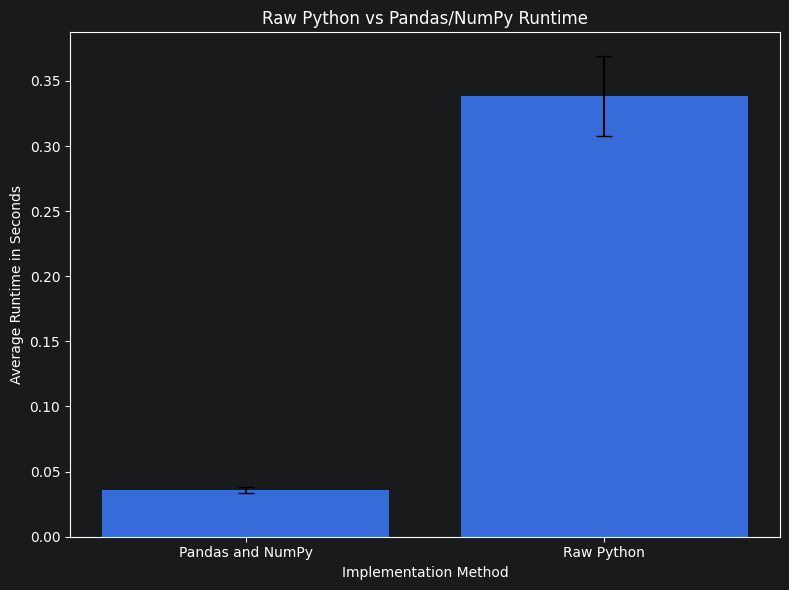

Performance figure saved successfully.
E:\Projects\DataMining\outputs\figures\14_python_vs_pandas_runtime.png
True


In [16]:
method_names = performance_summary[
    "method"
].tolist()


average_times = performance_summary[
    "average_seconds"
].tolist()


standard_deviations = (
    performance_summary[
        "standard_deviation_seconds"
    ]
    .fillna(0)
    .tolist()
)


plt.figure(figsize=(8, 6))


plt.bar(
    method_names,
    average_times,
    yerr=standard_deviations,
    capsize=6,
)


plt.title(
    "Raw Python vs Pandas/NumPy Runtime"
)
plt.xlabel("Implementation Method")
plt.ylabel("Average Runtime in Seconds")
plt.tight_layout()


performance_figure_path = (
    FIGURES_DIR
    / "14_python_vs_pandas_runtime.png"
)


plt.savefig(
    performance_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()
plt.close()


print("Performance figure saved successfully.")
print(performance_figure_path)
print(performance_figure_path.exists())

## Why Vectorized Operations Are Usually Faster

Raw Python processes values one at a time. Each loop iteration requires
Python to interpret instructions, access objects, check their types, and
perform operations separately.

Pandas and NumPy use vectorized operations. Instead of executing one
Python instruction for every row, they pass an entire array or column to
optimized low-level routines.

Many of these routines are implemented in compiled languages such as C.
This reduces Python interpreter overhead, improves memory access
patterns, and allows large groups of values to be processed together.

The performance advantage becomes more visible as the number of rows and
columns increases.

For very small datasets, library initialization and DataFrame overhead
may reduce the visible speed difference. The benchmark dataset was
therefore expanded by repeating the original rows. This expansion was
used only for runtime measurement and did not affect the machine-learning
models or evaluation results.

In [17]:
benchmark_conclusion = pd.DataFrame(
    [
        {
            "comparison_task": (
                "Numeric preprocessing and "
                "descriptive statistics"
            ),
            "raw_python_method": (
                "Loops, lists, and dictionaries"
            ),
            "vectorized_method": (
                "Pandas and NumPy operations"
            ),
            "outputs_equivalent": bool(
                output_validation[
                    "values_match"
                ].all()
            ),
            "faster_method": faster_method,
            "speedup_ratio": speedup_ratio,
            "main_reason": (
                "Vectorized compiled operations "
                "reduce Python interpreter overhead"
            ),
        }
    ]
)


display(
    benchmark_conclusion.round(4)
)

,comparison_task,raw_python_method,vectorized_method,outputs_equivalent,faster_method,speedup_ratio,main_reason
0,Numeric preprocessing and descriptive statistics,"Loops, lists, and dictionaries",Pandas and NumPy operations,True,Pandas and NumPy,9.4112,Vectorized compiled operations reduce Python i...


In [18]:
benchmark_dataset_summary.to_csv(
    TABLES_DIR
    / "14_benchmark_dataset_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


raw_python_preview.to_csv(
    TABLES_DIR
    / "14_raw_python_results.csv",
    index=False,
    encoding="utf-8-sig",
)


pandas_numpy_preview.to_csv(
    TABLES_DIR
    / "14_pandas_numpy_results.csv",
    index=False,
    encoding="utf-8-sig",
)


output_validation.to_csv(
    TABLES_DIR
    / "14_output_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


benchmark_timings.to_csv(
    TABLES_DIR
    / "14_benchmark_timings.csv",
    index=False,
    encoding="utf-8-sig",
)


performance_summary.to_csv(
    TABLES_DIR
    / "14_performance_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


speedup_summary.to_csv(
    TABLES_DIR
    / "14_speedup_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


benchmark_conclusion.to_csv(
    TABLES_DIR
    / "14_benchmark_conclusion.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 14 outputs saved successfully.")

Stage 14 outputs saved successfully.


In [19]:
assert df_raw.shape == (920, 16), (
    "The original dataset shape changed unexpectedly."
)


assert len(benchmark_df) == (
    len(df_raw) * BENCHMARK_MULTIPLIER
), (
    "The benchmark dataset size is incorrect."
)


assert len(raw_python_preview) == len(
    NUMERIC_FEATURES
), (
    "The Raw Python result has an incorrect number of rows."
)


assert len(pandas_numpy_preview) == len(
    NUMERIC_FEATURES
), (
    "The Pandas/NumPy result has an incorrect number of rows."
)


assert output_validation[
    "values_match"
].all(), (
    "The two implementations produced different results."
)


assert len(benchmark_timings) == (
    BENCHMARK_REPEATS * 2
), (
    "The timing table has an incorrect number of rows."
)


assert (
    benchmark_timings[
        "elapsed_seconds"
    ] > 0
).all(), (
    "All runtime values must be positive."
)


assert speedup_ratio > 0, (
    "The speedup ratio must be positive."
)


required_output_files = [
    TABLES_DIR
    / "14_benchmark_dataset_summary.csv",
    TABLES_DIR
    / "14_raw_python_results.csv",
    TABLES_DIR
    / "14_pandas_numpy_results.csv",
    TABLES_DIR
    / "14_output_validation.csv",
    TABLES_DIR
    / "14_benchmark_timings.csv",
    TABLES_DIR
    / "14_performance_summary.csv",
    TABLES_DIR
    / "14_speedup_summary.csv",
    TABLES_DIR
    / "14_benchmark_conclusion.csv",
    FIGURES_DIR
    / "14_python_vs_pandas_runtime.png",
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 14 validation checks passed.")

All Stage 14 validation checks passed.
